<a href="https://colab.research.google.com/github/jyeon6273/DeepNeuralNetworks/blob/main/MNIST_ANN_Training_Lab_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab: Training an ANN on MNIST — What Changes Learning?

**Goal:** connect the lecture concepts to a practical PyTorch experiment.

We will keep one **baseline network** and change **one factor at a time**:

1. Batch size: **16 vs 32**
2. Network depth: **1 vs 2 vs 3 hidden layers**
3. Activation: **Sigmoid vs ReLU**
4. Learning rate
5. Optimizer
6. Dropout regularization

For every experiment we will compare:

- training loss
- validation loss
- training accuracy
- validation accuracy
- final test loss
- final test accuracy
- training time

> **Important experimental rule:** change only one factor at a time.  
> Otherwise, we cannot tell which change caused the difference.

## Connection to the lecture

The lecture uses MNIST as the running example: a **28×28 grayscale image** is flattened to **784 input features**, then passed through a hidden layer and a 10-class output layer.

The training loop follows the same logic discussed in class:

**Forward pass → loss → backpropagation → optimizer update → repeat on mini-batches**

In PyTorch, the core steps are:

```python
optimizer.zero_grad()
logits = model(x)
loss = criterion(logits, y)
loss.backward()
optimizer.step()
```

We will also test the lecture's ideas about hidden layers, nonlinear activation, learning rate, mini-batches, optimizers, and dropout.

## 0. Setup


In [ ]:
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Use 5 epochs for the lab. Increase to 8–10 if you want clearer separation.
EPOCHS = 5

# Optional quick demo mode.
FAST_MODE = False

print("Device:", DEVICE)
print("PyTorch version:", torch.__version__)

Device: cuda
PyTorch version: 2.11.0+cu128


### Reproducibility helper

Using the same random seed makes comparisons more controlled.

In [ ]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

## 1. Load MNIST

We normalize the pixel values to roughly zero mean / unit scale using the standard MNIST statistics.

We split the original training set into:

- **55,000 training images**
- **5,000 validation images**

The official **10,000-image test set** is kept separate until evaluation.

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

full_train = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

set_seed()
train_dataset, val_dataset = random_split(
    full_train,
    [55000, 5000],
    generator=torch.Generator().manual_seed(SEED)
)

if FAST_MODE:
    # Quick demonstration subset. Keep the validation/test sets reasonably sized.
    train_dataset = Subset(train_dataset, range(15000))
    val_dataset = Subset(val_dataset, range(3000))
    test_dataset = Subset(test_dataset, range(3000))

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Training samples: 55000
Validation samples: 5000
Test samples: 10000


### Look at a few MNIST images

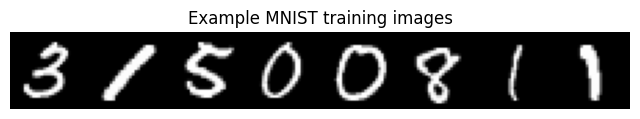

Labels: [3, 1, 5, 0, 0, 8, 1, 1]


In [ ]:
loader_preview = DataLoader(train_dataset, batch_size=8, shuffle=True)
images, labels = next(iter(loader_preview))

plt.figure(figsize=(8, 2))
grid = torch.cat([img.squeeze(0) for img in images], dim=1)
plt.imshow(grid, cmap="gray")
plt.axis("off")
plt.title("Example MNIST training images")
plt.show()

print("Labels:", labels.tolist())

## 2. Flexible MLP model

Instead of rewriting a new class for every experiment, we create one model builder.

Parameters we can change:

- `hidden_sizes`: number and size of hidden layers
- `activation`: ReLU or Sigmoid
- `dropout`: probability of dropping hidden activations

The output layer has **10 logits**, one for each digit class.

> We do **not** add `Softmax` inside the model because `nn.CrossEntropyLoss()` expects raw logits and applies the needed log-softmax internally.

In [ ]:
class MLP(nn.Module):
    def __init__(
        self,
        hidden_sizes=(128,),
        activation="relu",
        dropout=0.0
    ):
        super().__init__()

        activation = activation.lower()
        if activation == "relu":
            act_cls = nn.ReLU
        elif activation == "sigmoid":
            act_cls = nn.Sigmoid
        else:
            raise ValueError("activation must be 'relu' or 'sigmoid'")

        layers = [nn.Flatten()]
        in_features = 28 * 28

        for hidden in hidden_sizes:
            layers.append(nn.Linear(in_features, hidden))
            layers.append(act_cls())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            in_features = hidden

        layers.append(nn.Linear(in_features, 10))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


baseline_model = MLP(hidden_sizes=(128,), activation="relu", dropout=0.0)
print(baseline_model)

n_params = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

MLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)
Trainable parameters: 101,770


## 3. Training and evaluation functions

In [ ]:
criterion = nn.CrossEntropyLoss()


def make_loaders(batch_size):
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=256,
        shuffle=False,
        num_workers=0
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=256,
        shuffle=False,
        num_workers=0
    )
    return train_loader, val_loader, test_loader


def make_optimizer(name, parameters, lr):
    name = name.lower()

    if name == "sgd":
        return torch.optim.SGD(parameters, lr=lr)

    if name == "sgd_momentum":
        return torch.optim.SGD(parameters, lr=lr, momentum=0.9)

    if name == "adam":
        return torch.optim.Adam(parameters, lr=lr)

    if name == "rmsprop":
        return torch.optim.RMSprop(parameters, lr=lr)

    raise ValueError(f"Unknown optimizer: {name}")


def evaluate(model, loader):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            logits = model(x)
            loss = criterion(logits, y)

            batch_n = y.size(0)
            total_loss += loss.item() * batch_n
            total_correct += (logits.argmax(dim=1) == y).sum().item()
            total_samples += batch_n

    return (
        total_loss / total_samples,
        total_correct / total_samples
    )


def train_model(model, train_loader, val_loader, optimizer, epochs=EPOCHS):
    model = model.to(DEVICE)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()

        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            # 1. Clear old gradients
            optimizer.zero_grad()

            # 2. Forward propagation
            logits = model(x)

            # 3. Compute loss
            loss = criterion(logits, y)

            # 4. Backpropagation: compute gradients
            loss.backward()

            # 5. Update weights
            optimizer.step()

            batch_n = y.size(0)
            total_loss += loss.item() * batch_n
            total_correct += (logits.argmax(dim=1) == y).sum().item()
            total_samples += batch_n

        train_loss = total_loss / total_samples
        train_acc = total_correct / total_samples

        val_loss, val_acc = evaluate(model, val_loader)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss {train_loss:.4f} | "
            f"train acc {train_acc:.4f} | "
            f"val loss {val_loss:.4f} | "
            f"val acc {val_acc:.4f}"
        )

    elapsed = time.perf_counter() - start
    return history, elapsed

## 4. Experiment runner

This function trains one configuration and stores both its learning curves and its final test result.

In [ ]:
all_results = []
all_histories = {}


def run_experiment(
    experiment,
    name,
    hidden_sizes=(128,),
    activation="relu",
    batch_size=32,
    lr=1e-3,
    optimizer_name="adam",
    dropout=0.0,
    epochs=EPOCHS
):
    set_seed()

    train_loader, val_loader, test_loader = make_loaders(batch_size)

    model = MLP(
        hidden_sizes=hidden_sizes,
        activation=activation,
        dropout=dropout
    ).to(DEVICE)

    optimizer = make_optimizer(
        optimizer_name,
        model.parameters(),
        lr=lr
    )

    print("=" * 75)
    print(f"{experiment}: {name}")
    print(
        f"layers={hidden_sizes}, activation={activation}, "
        f"batch={batch_size}, lr={lr}, optimizer={optimizer_name}, "
        f"dropout={dropout}"
    )

    history, seconds = train_model(
        model, train_loader, val_loader, optimizer, epochs=epochs
    )

    test_loss, test_acc = evaluate(model, test_loader)

    n_params = sum(
        p.numel() for p in model.parameters() if p.requires_grad
    )

    row = {
        "Experiment": experiment,
        "Configuration": name,
        "Hidden Layers": str(hidden_sizes),
        "Activation": activation,
        "Batch Size": batch_size,
        "Learning Rate": lr,
        "Optimizer": optimizer_name,
        "Dropout": dropout,
        "Parameters": n_params,
        "Final Train Loss": history["train_loss"][-1],
        "Final Train Accuracy": history["train_acc"][-1],
        "Final Val Loss": history["val_loss"][-1],
        "Final Val Accuracy": history["val_acc"][-1],
        "Test Loss": test_loss,
        "Test Accuracy": test_acc,
        "Train Time (s)": seconds
    }

    all_results.append(row)
    all_histories[(experiment, name)] = history

    print(f"\nTEST -> loss: {test_loss:.4f}, accuracy: {test_acc:.4f}")
    return row

## 5. Plotting helper

Each experiment gets:

1. **Loss vs epoch**
2. **Accuracy vs epoch**
3. **Final test accuracy bar chart**
4. **Final test loss bar chart**
5. A numerical comparison table

In [ ]:
def plot_experiment(experiment_name):
    rows = [r for r in all_results if r["Experiment"] == experiment_name]

    if not rows:
        print("No results found for:", experiment_name)
        return

    styles = [
        {"linestyle": "--", "marker": "o"},
        {"linestyle": "--", "marker": "s"},
        {"linestyle": "-",  "marker": "^"},
        {"linestyle": "-",  "marker": "D"},
    ]

    # -----------------------------
    # Validation Loss
    # -----------------------------
    plt.figure(figsize=(9, 5))

    for i, r in enumerate(rows):
        h = all_histories[
            (experiment_name, r["Configuration"])
        ]

        epochs = range(1, len(h["val_loss"]) + 1)

        plt.plot(
            epochs,
            h["val_loss"],
            label=r["Configuration"],
            linewidth=2,
            markersize=7,
            alpha=0.8,
            **styles[i % len(styles)]
        )

    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.title(f"{experiment_name}: Validation Loss")
    plt.xticks(range(1, max(len(
        all_histories[(experiment_name, r["Configuration"])]["val_loss"]
    ) for r in rows) + 1))
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()

    # -----------------------------
    # Validation Accuracy
    # -----------------------------
    plt.figure(figsize=(9, 5))

    for i, r in enumerate(rows):
        h = all_histories[
            (experiment_name, r["Configuration"])
        ]

        epochs = range(1, len(h["val_acc"]) + 1)

        plt.plot(
            epochs,
            [100 * x for x in h["val_acc"]],
            label=r["Configuration"],
            linewidth=2,
            markersize=7,
            alpha=0.8,
            **styles[i % len(styles)]
        )

    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy (%)")
    plt.title(f"{experiment_name}: Validation Accuracy")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()

    # -----------------------------
    # Table
    # -----------------------------
    df = pd.DataFrame(rows)

    display_cols = [
        "Configuration",
        "Final Train Loss",
        "Final Train Accuracy",
        "Final Val Loss",
        "Final Val Accuracy",
        "Test Loss",
        "Test Accuracy",
        "Train Time (s)"
    ]

    table = df[display_cols].copy()

    for col in [
        "Final Train Accuracy",
        "Final Val Accuracy",
        "Test Accuracy"
    ]:
        table[col] = (100 * table[col]).round(2)

    for col in [
        "Final Train Loss",
        "Final Val Loss",
        "Test Loss"
    ]:
        table[col] = table[col].round(4)

    table["Train Time (s)"] = table["Train Time (s)"].round(1)

    return table

# Experiment 1 — Batch Size

### Question
How does the number of samples used for one gradient update affect training?

Compare:

- **Batch size = 16**
- **Batch size = 32**

Everything else stays the same:

- 1 hidden layer with 128 neurons
- ReLU
- Adam
- learning rate = 0.001
- no dropout

### Before running
Ask students:

> Which batch size will make **more weight updates per epoch**?

> Which one do you expect to train faster per epoch?

> Do you expect the final accuracy to be very different?

1. Batch Size: Batch 16
layers=(128,), activation=relu, batch=16, lr=0.001, optimizer=adam, dropout=0.0
Epoch 01/5 | train loss 0.2144 | train acc 0.9359 | val loss 0.1319 | val acc 0.9578
Epoch 02/5 | train loss 0.1011 | train acc 0.9692 | val loss 0.1496 | val acc 0.9558
Epoch 03/5 | train loss 0.0750 | train acc 0.9759 | val loss 0.1073 | val acc 0.9674
Epoch 04/5 | train loss 0.0586 | train acc 0.9816 | val loss 0.1140 | val acc 0.9706
Epoch 05/5 | train loss 0.0502 | train acc 0.9841 | val loss 0.1293 | val acc 0.9672

TEST -> loss: 0.1074, accuracy: 0.9710
1. Batch Size: Batch 32
layers=(128,), activation=relu, batch=32, lr=0.001, optimizer=adam, dropout=0.0
Epoch 01/5 | train loss 0.2317 | train acc 0.9313 | val loss 0.1446 | val acc 0.9560
Epoch 02/5 | train loss 0.1040 | train acc 0.9681 | val loss 0.1263 | val acc 0.9624
Epoch 03/5 | train loss 0.0725 | train acc 0.9773 | val loss 0.0984 | val acc 0.9702
Epoch 04/5 | train loss 0.0557 | train acc 0.9818 | val loss 0.1050 | va

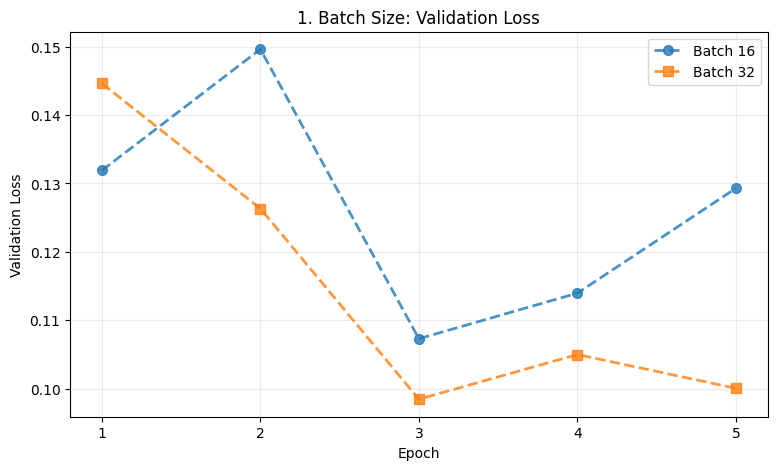

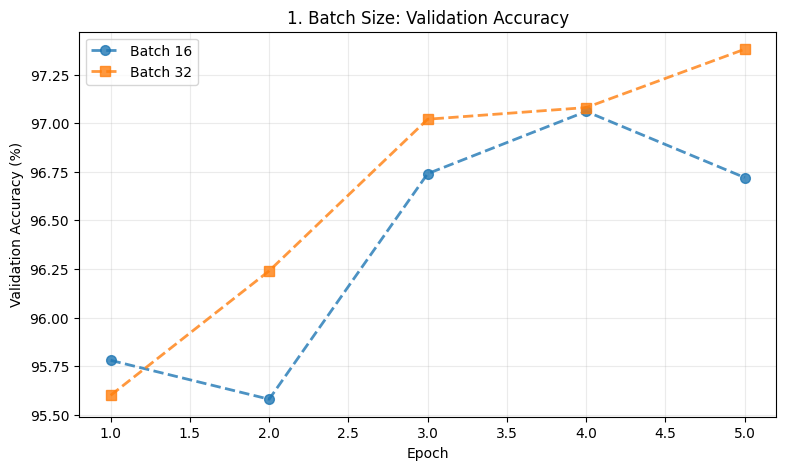

,Configuration,Final Train Loss,Final Train Accuracy,Final Val Loss,Final Val Accuracy,Test Loss,Test Accuracy,Train Time (s)
0,Batch 16,0.0502,98.41,0.1293,96.72,0.1074,97.10,100.7
1,Batch 32,0.0450,98.52,0.1000,97.38,0.0793,97.68,79.1


In [ ]:
run_experiment(
    "1. Batch Size",
    "Batch 16",
    batch_size=16
)

run_experiment(
    "1. Batch Size",
    "Batch 32",
    batch_size=32
)

plot_experiment("1. Batch Size")

### Student task 1

Complete:

- Batch size 16 makes ______ optimizer updates per epoch than batch size 32.
- Smaller batches usually produce ______ gradient estimates.
- Did the smaller batch produce better accuracy here?
- Was the difference large enough to justify a general rule?

> **Teaching point:** one MNIST run is evidence for this experiment, not proof that one batch size is always better.

# Experiment 2 — Number of Hidden Layers

The lecture explains that hidden layers increase the network's ability to represent complex nonlinear functions.

Compare:

- **1 hidden layer:** 128
- **2 hidden layers:** 128 → 64
- **3 hidden layers:** 128 → 64 → 32

All other settings are fixed.

2. Hidden Layers: 1 hidden layer
layers=(128,), activation=relu, batch=32, lr=0.001, optimizer=adam, dropout=0.0
Epoch 01/5 | train loss 0.2317 | train acc 0.9313 | val loss 0.1446 | val acc 0.9560
Epoch 02/5 | train loss 0.1040 | train acc 0.9681 | val loss 0.1263 | val acc 0.9624
Epoch 03/5 | train loss 0.0725 | train acc 0.9773 | val loss 0.0984 | val acc 0.9702
Epoch 04/5 | train loss 0.0557 | train acc 0.9818 | val loss 0.1050 | val acc 0.9708
Epoch 05/5 | train loss 0.0450 | train acc 0.9852 | val loss 0.1000 | val acc 0.9738

TEST -> loss: 0.0793, accuracy: 0.9768
2. Hidden Layers: 2 hidden layers
layers=(128, 64), activation=relu, batch=32, lr=0.001, optimizer=adam, dropout=0.0
Epoch 01/5 | train loss 0.2495 | train acc 0.9242 | val loss 0.1511 | val acc 0.9550
Epoch 02/5 | train loss 0.1095 | train acc 0.9671 | val loss 0.1112 | val acc 0.9644
Epoch 03/5 | train loss 0.0781 | train acc 0.9756 | val loss 0.1231 | val acc 0.9622
Epoch 04/5 | train loss 0.0628 | train acc 0.9801 

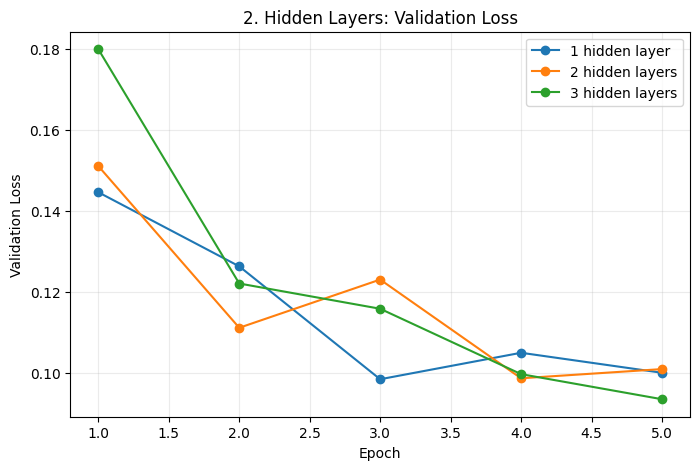

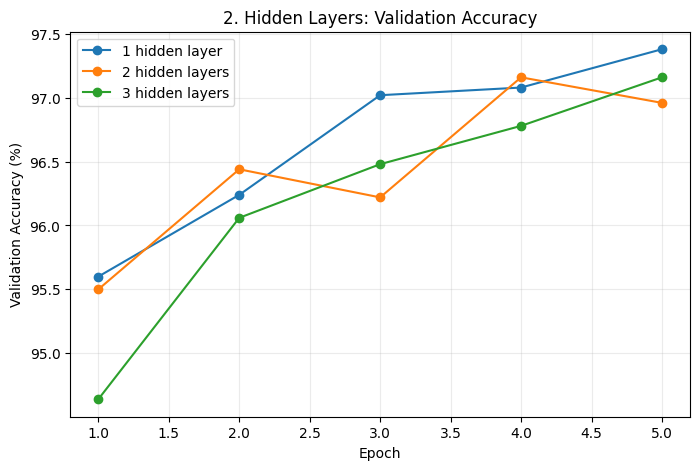

,Configuration,Final Train Loss,Final Train Accuracy,Final Val Loss,Final Val Accuracy,Test Loss,Test Accuracy,Train Time (s)
0,1 hidden layer,0.0450,98.52,0.1000,97.38,0.0793,97.68,73.5
1,2 hidden layers,0.0485,98.44,0.1009,96.96,0.0791,97.62,76.6
2,3 hidden layers,0.0581,98.19,0.0935,97.16,0.0849,97.37,83.8


In [ ]:
run_experiment(
    "2. Hidden Layers",
    "1 hidden layer",
    hidden_sizes=(128,)
)

run_experiment(
    "2. Hidden Layers",
    "2 hidden layers",
    hidden_sizes=(128, 64)
)

run_experiment(
    "2. Hidden Layers",
    "3 hidden layers",
    hidden_sizes=(128, 64, 32)
)

plot_experiment("2. Hidden Layers")

2. Hidden Layers: 1 hidden layer (epochs=10)
layers=(128,), activation=relu, batch=32, lr=0.001, optimizer=adam, dropout=0.0
Epoch 01/10 | train loss 0.2317 | train acc 0.9313 | val loss 0.1446 | val acc 0.9560
Epoch 02/10 | train loss 0.1040 | train acc 0.9681 | val loss 0.1263 | val acc 0.9624
Epoch 03/10 | train loss 0.0725 | train acc 0.9773 | val loss 0.0984 | val acc 0.9702
Epoch 04/10 | train loss 0.0557 | train acc 0.9818 | val loss 0.1050 | val acc 0.9708
Epoch 05/10 | train loss 0.0450 | train acc 0.9852 | val loss 0.1000 | val acc 0.9738
Epoch 06/10 | train loss 0.0388 | train acc 0.9871 | val loss 0.0913 | val acc 0.9758
Epoch 07/10 | train loss 0.0299 | train acc 0.9901 | val loss 0.1187 | val acc 0.9702
Epoch 08/10 | train loss 0.0264 | train acc 0.9909 | val loss 0.1117 | val acc 0.9724
Epoch 09/10 | train loss 0.0260 | train acc 0.9914 | val loss 0.1128 | val acc 0.9720
Epoch 10/10 | train loss 0.0220 | train acc 0.9920 | val loss 0.0976 | val acc 0.9758

TEST -> loss: 

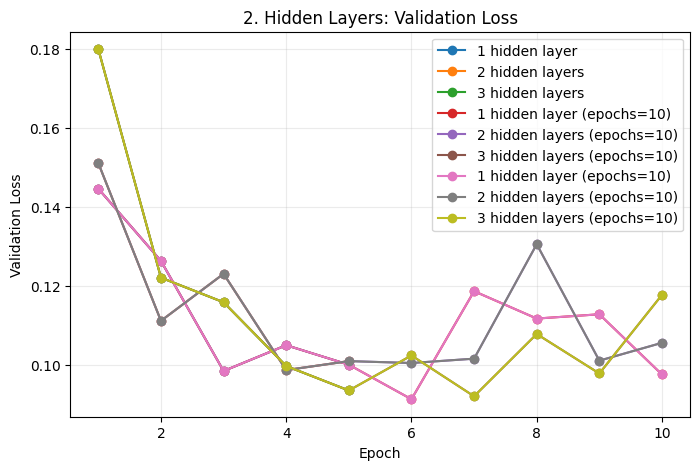

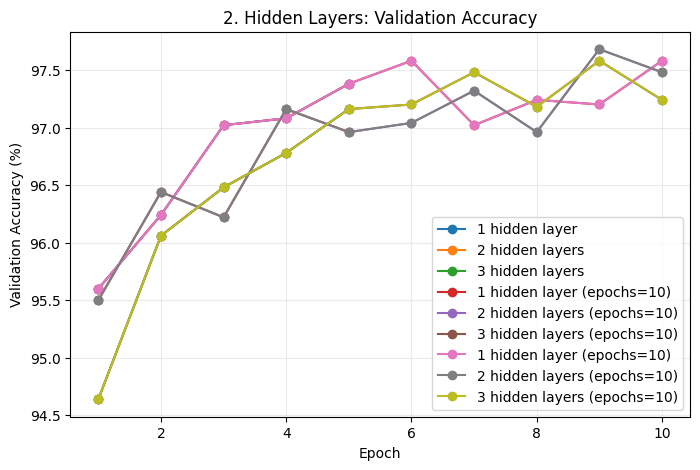

,Configuration,Final Train Loss,Final Train Accuracy,Final Val Loss,Final Val Accuracy,Test Loss,Test Accuracy,Train Time (s)
0,1 hidden layer,0.0450,98.52,0.1000,97.38,0.0793,97.68,73.5
1,2 hidden layers,0.0485,98.44,0.1009,96.96,0.0791,97.62,76.6
2,3 hidden layers,0.0581,98.19,0.0935,97.16,0.0849,97.37,83.8
3,1 hidden layer (epochs=10),0.0450,98.52,0.1000,97.38,0.0793,97.68,74.6
4,2 hidden layers (epochs=10),0.0485,98.44,0.1009,96.96,0.0791,97.62,81.1
5,3 hidden layers (epochs=10),0.0581,98.19,0.0935,97.16,0.0849,97.37,77.9
6,1 hidden layer (epochs=10),0.0220,99.20,0.0976,97.58,0.0964,97.68,146.4
7,2 hidden layers (epochs=10),0.0277,99.08,0.1056,97.48,0.0913,97.81,156.2
8,3 hidden layers (epochs=10),0.0299,98.98,0.1177,97.24,0.1082,97.44,163.1


In [ ]:
run_experiment(
    "2. Hidden Layers",
    "1 hidden layer (epochs=10)",
    hidden_sizes=(128,),
    epochs=10,
)

run_experiment(
    "2. Hidden Layers",
    "2 hidden layers (epochs=10)",
    hidden_sizes=(128, 64),
    epochs=10,
)

run_experiment(
    "2. Hidden Layers",
    "3 hidden layers (epochs=10)",
    hidden_sizes=(128, 64, 32),
    epochs=10,
)

plot_experiment("2. Hidden Layers")

### Student task 2

Discuss:

1. Does increasing depth always improve MNIST test accuracy?
2. Which model has the most trainable parameters?
3. Does the deeper network train more slowly?
4. Why might a more expressive model fail to improve the test result?

**Key idea:** more capacity is useful only if the optimization problem, data, and task benefit from it.

# Experiment 3 — Sigmoid vs ReLU

The lecture emphasizes nonlinear activation functions.

Compare the **same network** using:

- Sigmoid
- ReLU

### Before running

Ask:

> Which activation do you expect to learn faster?

Sigmoid outputs are bounded between 0 and 1.  
ReLU keeps positive values and clips negative values to zero.

3. Activation: Sigmoid
layers=(128,), activation=sigmoid, batch=32, lr=0.001, optimizer=adam, dropout=0.0
Epoch 01/5 | train loss 0.3466 | train acc 0.9087 | val loss 0.2124 | val acc 0.9348
Epoch 02/5 | train loss 0.1605 | train acc 0.9537 | val loss 0.1525 | val acc 0.9526
Epoch 03/5 | train loss 0.1134 | train acc 0.9679 | val loss 0.1272 | val acc 0.9608
Epoch 04/5 | train loss 0.0867 | train acc 0.9760 | val loss 0.1176 | val acc 0.9638
Epoch 05/5 | train loss 0.0692 | train acc 0.9807 | val loss 0.1099 | val acc 0.9648

TEST -> loss: 0.0971, accuracy: 0.9705
3. Activation: ReLU
layers=(128,), activation=relu, batch=32, lr=0.001, optimizer=adam, dropout=0.0
Epoch 01/5 | train loss 0.2317 | train acc 0.9313 | val loss 0.1446 | val acc 0.9560
Epoch 02/5 | train loss 0.1040 | train acc 0.9681 | val loss 0.1263 | val acc 0.9624
Epoch 03/5 | train loss 0.0725 | train acc 0.9773 | val loss 0.0984 | val acc 0.9702
Epoch 04/5 | train loss 0.0557 | train acc 0.9818 | val loss 0.1050 | val 

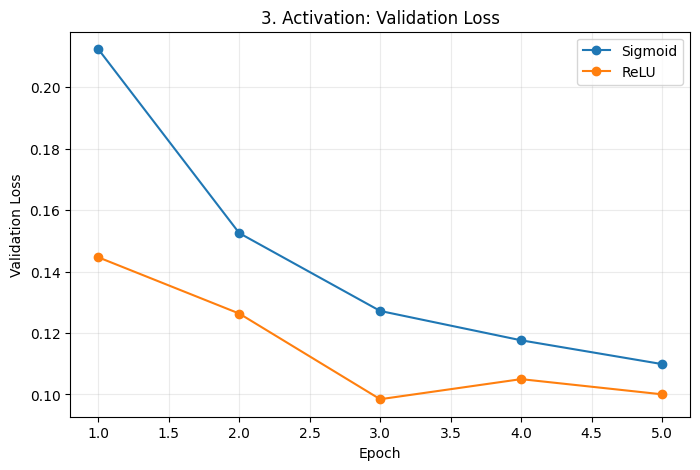

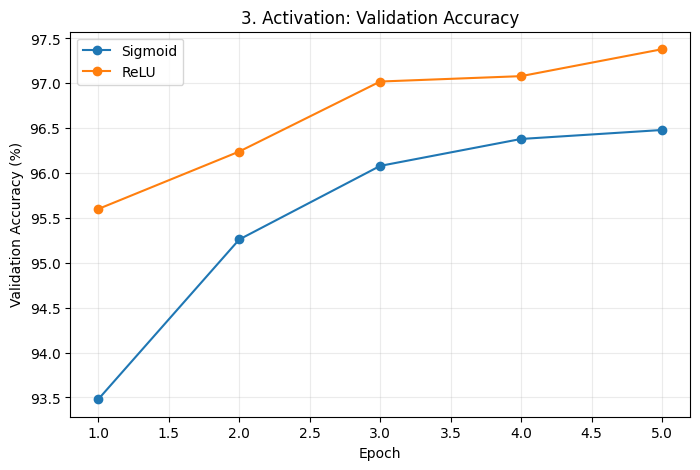

,Configuration,Final Train Loss,Final Train Accuracy,Final Val Loss,Final Val Accuracy,Test Loss,Test Accuracy,Train Time (s)
0,Sigmoid,0.0692,98.07,0.1099,96.48,0.0971,97.05,74.5
1,ReLU,0.0450,98.52,0.1000,97.38,0.0793,97.68,73.6


In [ ]:
run_experiment(
    "3. Activation",
    "Sigmoid",
    activation="sigmoid"
)

run_experiment(
    "3. Activation",
    "ReLU",
    activation="relu"
)

plot_experiment("3. Activation")

3. Activation: Sigmoid (10 epochs)
layers=(128,), activation=sigmoid, batch=32, lr=0.001, optimizer=adam, dropout=0.0
Epoch 01/10 | train loss 0.3466 | train acc 0.9087 | val loss 0.2124 | val acc 0.9348
Epoch 02/10 | train loss 0.1605 | train acc 0.9537 | val loss 0.1525 | val acc 0.9526
Epoch 03/10 | train loss 0.1134 | train acc 0.9679 | val loss 0.1272 | val acc 0.9608
Epoch 04/10 | train loss 0.0867 | train acc 0.9760 | val loss 0.1176 | val acc 0.9638
Epoch 05/10 | train loss 0.0692 | train acc 0.9807 | val loss 0.1099 | val acc 0.9648
Epoch 06/10 | train loss 0.0547 | train acc 0.9851 | val loss 0.0992 | val acc 0.9702
Epoch 07/10 | train loss 0.0447 | train acc 0.9882 | val loss 0.0994 | val acc 0.9680
Epoch 08/10 | train loss 0.0360 | train acc 0.9907 | val loss 0.0946 | val acc 0.9698
Epoch 09/10 | train loss 0.0297 | train acc 0.9926 | val loss 0.0958 | val acc 0.9676
Epoch 10/10 | train loss 0.0244 | train acc 0.9944 | val loss 0.0910 | val acc 0.9718

TEST -> loss: 0.0868,

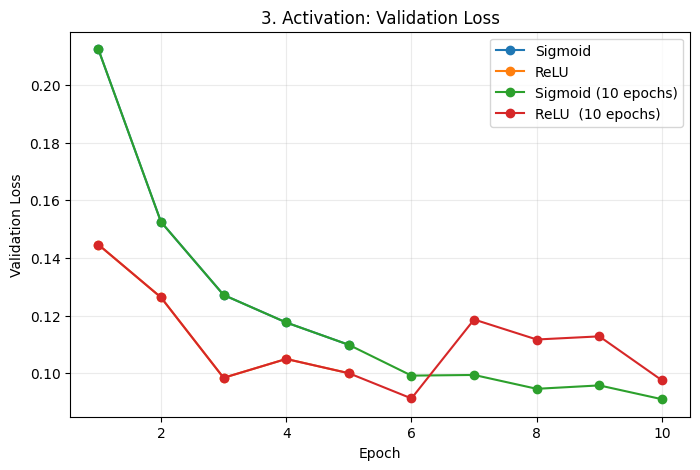

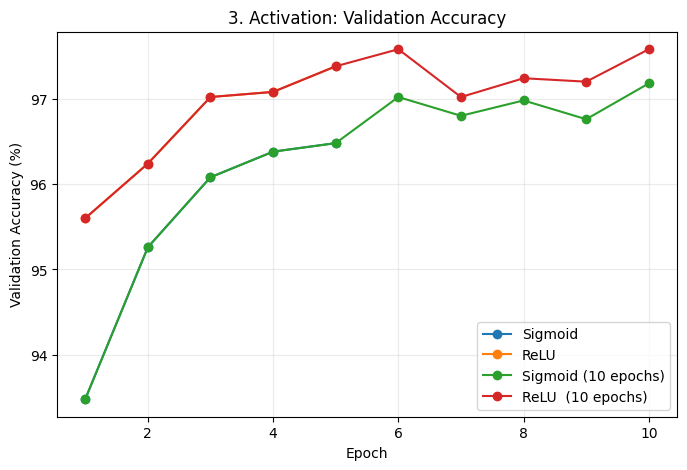

,Configuration,Final Train Loss,Final Train Accuracy,Final Val Loss,Final Val Accuracy,Test Loss,Test Accuracy,Train Time (s)
0,Sigmoid,0.0692,98.07,0.1099,96.48,0.0971,97.05,74.5
1,ReLU,0.0450,98.52,0.1000,97.38,0.0793,97.68,73.6
2,Sigmoid (10 epochs),0.0244,99.44,0.0910,97.18,0.0868,97.35,146.8
3,ReLU (10 epochs),0.0220,99.20,0.0976,97.58,0.0964,97.68,150.5


In [ ]:
run_experiment(
    "3. Activation",
    "Sigmoid (10 epochs)",
    activation="sigmoid",
    epochs=10
)

run_experiment(
    "3. Activation",
    "ReLU  (10 epochs)",
    activation="relu",
    epochs=10
)

plot_experiment("3. Activation")

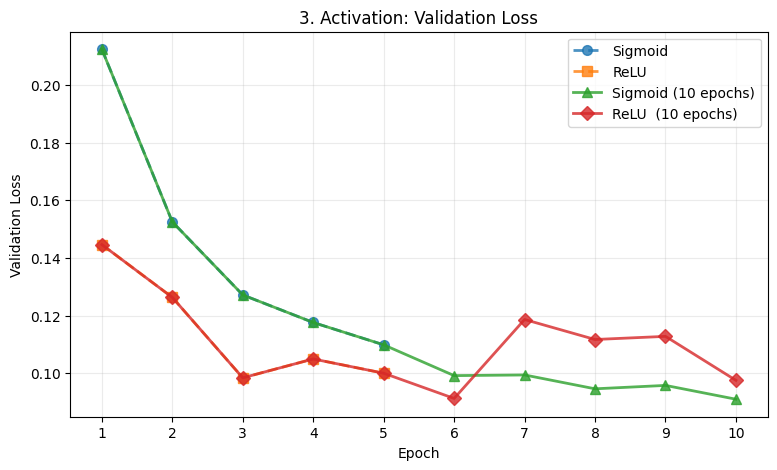

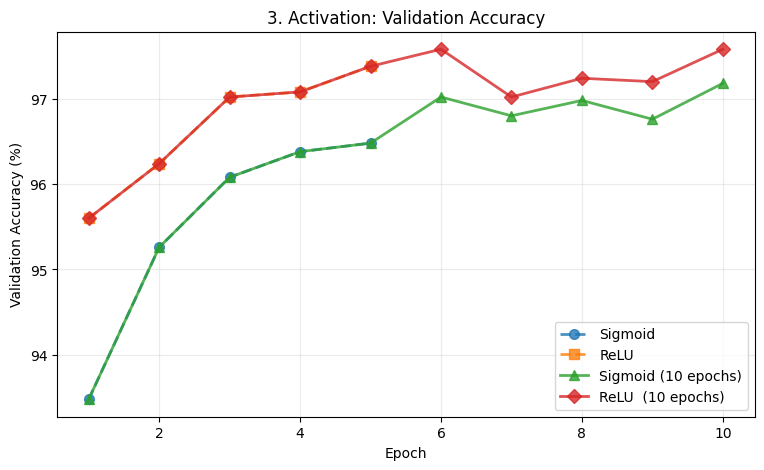

,Configuration,Final Train Loss,Final Train Accuracy,Final Val Loss,Final Val Accuracy,Test Loss,Test Accuracy,Train Time (s)
0,Sigmoid,0.0692,98.07,0.1099,96.48,0.0971,97.05,74.5
1,ReLU,0.0450,98.52,0.1000,97.38,0.0793,97.68,73.6
2,Sigmoid (10 epochs),0.0244,99.44,0.0910,97.18,0.0868,97.35,146.8
3,ReLU (10 epochs),0.0220,99.20,0.0976,97.58,0.0964,97.68,150.5


In [ ]:
plot_experiment("3. Activation")

### Optional: See the activation functions directly

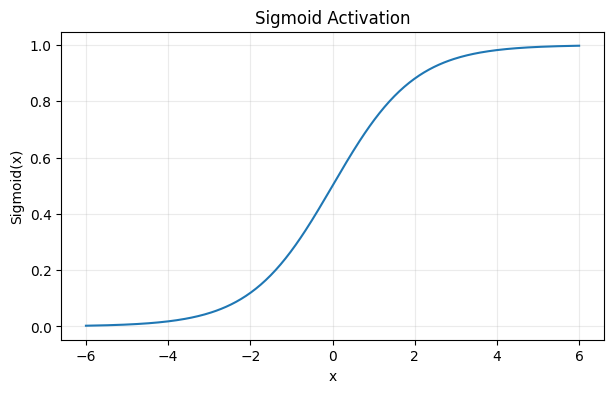

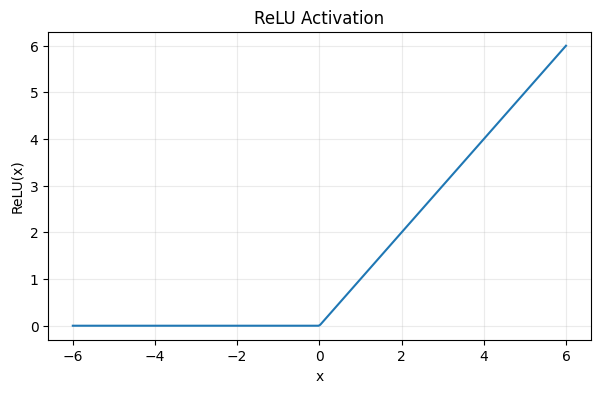

In [ ]:
x = torch.linspace(-6, 6, 300)

plt.figure(figsize=(7, 4))
plt.plot(x.numpy(), torch.sigmoid(x).numpy())
plt.xlabel("x")
plt.ylabel("Sigmoid(x)")
plt.title("Sigmoid Activation")
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(x.numpy(), torch.relu(x).numpy())
plt.xlabel("x")
plt.ylabel("ReLU(x)")
plt.title("ReLU Activation")
plt.grid(alpha=0.25)
plt.show()

### Student task 3

Look at the first and last epochs.

- Which activation reduces the loss faster?
- Which reaches higher validation accuracy?
- Why can sigmoid make gradient-based learning difficult in deeper networks?

Hint: think about what happens to the derivative when sigmoid becomes very close to 0 or 1.

# Experiment 4 — Learning Rate

The lecture describes the learning rate as the step size used when parameters move in the direction that reduces the loss.

Compare Adam with:

- `0.0001`
- `0.001`
- `0.01`

Only the learning rate changes.

### Prediction

- Too small → learning may be very slow.
- Reasonable → efficient convergence.
- Too large → unstable or overshooting updates can occur.

4. Learning Rate: lr=0.0001
layers=(128,), activation=relu, batch=32, lr=0.0001, optimizer=adam, dropout=0.0
Epoch 01/5 | train loss 0.4910 | train acc 0.8733 | val loss 0.3017 | val acc 0.9150
Epoch 02/5 | train loss 0.2529 | train acc 0.9285 | val loss 0.2389 | val acc 0.9270
Epoch 03/5 | train loss 0.1999 | train acc 0.9436 | val loss 0.2000 | val acc 0.9378
Epoch 04/5 | train loss 0.1646 | train acc 0.9542 | val loss 0.1739 | val acc 0.9500
Epoch 05/5 | train loss 0.1396 | train acc 0.9608 | val loss 0.1573 | val acc 0.9546

TEST -> loss: 0.1394, accuracy: 0.9596
4. Learning Rate: lr=0.001
layers=(128,), activation=relu, batch=32, lr=0.001, optimizer=adam, dropout=0.0
Epoch 01/5 | train loss 0.2317 | train acc 0.9313 | val loss 0.1446 | val acc 0.9560
Epoch 02/5 | train loss 0.1040 | train acc 0.9681 | val loss 0.1263 | val acc 0.9624
Epoch 03/5 | train loss 0.0725 | train acc 0.9773 | val loss 0.0984 | val acc 0.9702
Epoch 04/5 | train loss 0.0557 | train acc 0.9818 | val loss 0.1

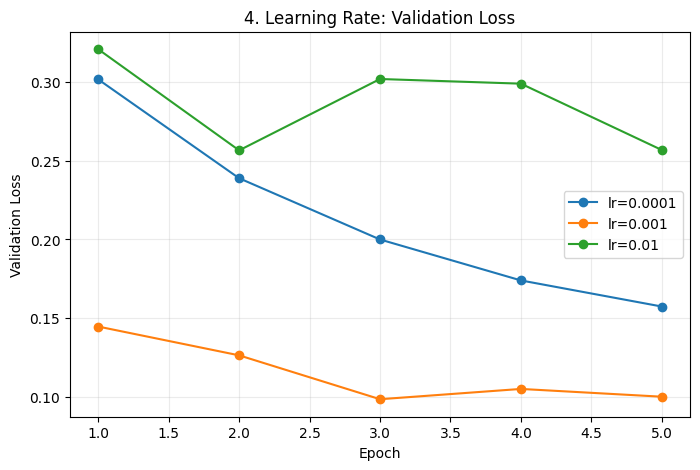

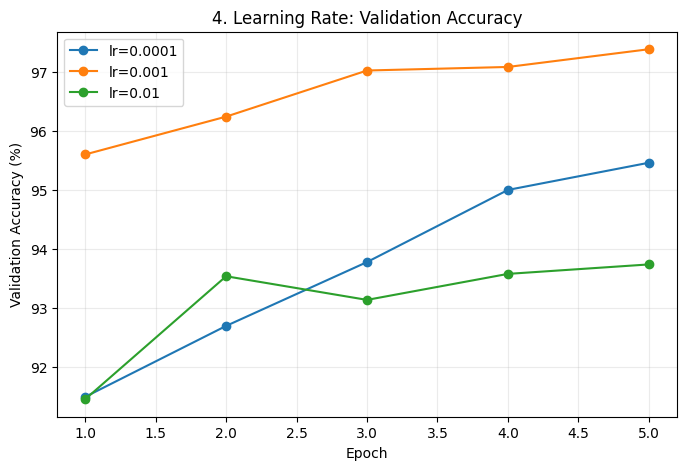

,Configuration,Final Train Loss,Final Train Accuracy,Final Val Loss,Final Val Accuracy,Test Loss,Test Accuracy,Train Time (s)
0,lr=0.0001,0.1396,96.08,0.1573,95.46,0.1394,95.96,78.9
1,lr=0.001,0.0450,98.52,0.1000,97.38,0.0793,97.68,77.6
2,lr=0.01,0.2232,94.33,0.2568,93.74,0.2391,94.43,77.9


In [ ]:
for lr in [1e-4, 1e-3, 1e-2]:
    run_experiment(
        "4. Learning Rate",
        f"lr={lr}",
        lr=lr
    )

plot_experiment("4. Learning Rate")

### Student task 4

Answer from the curves, not from theory alone:

1. Which learning rate reduced validation loss fastest?
2. Did the largest learning rate become unstable?
3. Did the smallest learning rate simply need more epochs?
4. Why is learning rate considered one of the most important hyperparameters?

# Experiment 5 — Optimizers

The optimizer decides **how gradients are converted into parameter updates**.

Compare:

- SGD
- SGD + Momentum
- RMSprop
- Adam

For a clean classroom comparison we use the **same learning rate (`0.001`)** for all four.

> This isolates the optimizer algorithm, but it does **not** mean `0.001` is the best learning rate for every optimizer. In real model tuning, each optimizer should usually receive its own learning-rate search.

5. Optimizer: sgd
layers=(128,), activation=relu, batch=32, lr=0.001, optimizer=sgd, dropout=0.0
Epoch 01/5 | train loss 1.2292 | train acc 0.7200 | val loss 0.6884 | val acc 0.8402
Epoch 02/5 | train loss 0.5533 | train acc 0.8650 | val loss 0.4820 | val acc 0.8744
Epoch 03/5 | train loss 0.4328 | train acc 0.8848 | val loss 0.4135 | val acc 0.8862
Epoch 04/5 | train loss 0.3824 | train acc 0.8945 | val loss 0.3783 | val acc 0.8926
Epoch 05/5 | train loss 0.3529 | train acc 0.9002 | val loss 0.3560 | val acc 0.8968

TEST -> loss: 0.3274, accuracy: 0.9085
5. Optimizer: sgd_momentum
layers=(128,), activation=relu, batch=32, lr=0.001, optimizer=sgd_momentum, dropout=0.0
Epoch 01/5 | train loss 0.4685 | train acc 0.8738 | val loss 0.2987 | val acc 0.9128
Epoch 02/5 | train loss 0.2509 | train acc 0.9289 | val loss 0.2371 | val acc 0.9296
Epoch 03/5 | train loss 0.1994 | train acc 0.9436 | val loss 0.1998 | val acc 0.9392
Epoch 04/5 | train loss 0.1656 | train acc 0.9535 | val loss 0.1761 

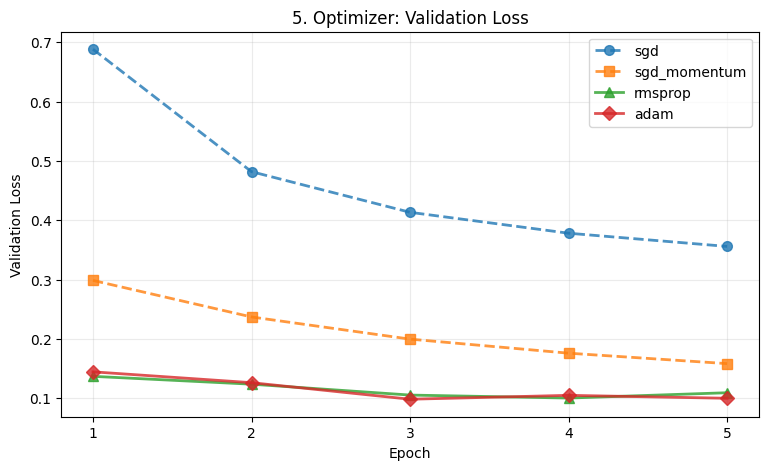

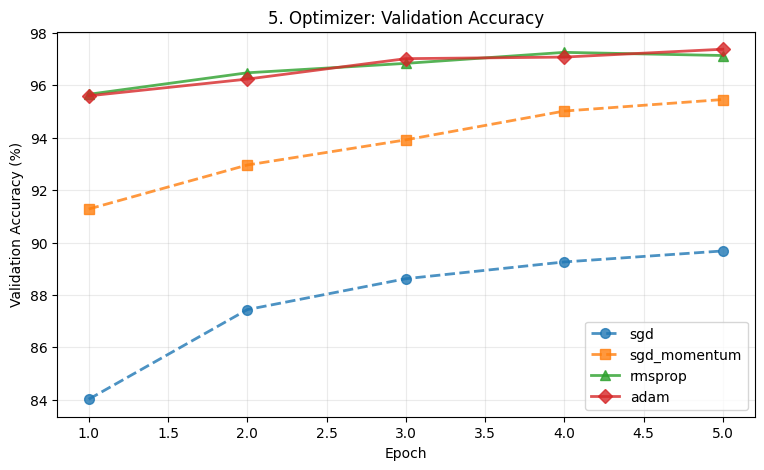

,Configuration,Final Train Loss,Final Train Accuracy,Final Val Loss,Final Val Accuracy,Test Loss,Test Accuracy,Train Time (s)
0,sgd,0.3529,90.02,0.3560,89.68,0.3274,90.85,70.5
1,sgd_momentum,0.1422,96.01,0.1584,95.46,0.1414,95.92,71.0
2,rmsprop,0.0476,98.47,0.1094,97.14,0.0902,97.60,72.3
3,adam,0.0450,98.52,0.1000,97.38,0.0793,97.68,76.3


In [ ]:
for opt in ["sgd", "sgd_momentum", "rmsprop", "adam"]:
    run_experiment(
        "5. Optimizer",
        opt,
        optimizer_name=opt,
        lr=1e-3
    )

plot_experiment("5. Optimizer")

### Student task 5

1. Which optimizer converged fastest under the same learning rate?
2. Is raw SGD doing badly because SGD is inherently poor, or because the learning rate may be unsuitable?
3. What extra idea does momentum add to SGD?
4. Why is it dangerous to say "Optimizer X is always best" from one experiment?

# Experiment 6 — Dropout Regularization

Dropout randomly removes hidden activations **during training**.

Compare:

- no dropout
- dropout = 0.3
- dropout = 0.5

During evaluation, PyTorch disables dropout automatically when we call:

```python
model.eval()
```

### Important expectation

On a relatively simple MNIST MLP, dropout may **not** always increase test accuracy.  
Its main purpose is to reduce overfitting and improve generalization. A useful sign is the difference between training and validation performance.

6. Dropout: Dropout 0.0
layers=(128,), activation=relu, batch=32, lr=0.001, optimizer=adam, dropout=0.0
Epoch 01/5 | train loss 0.2317 | train acc 0.9313 | val loss 0.1446 | val acc 0.9560
Epoch 02/5 | train loss 0.1040 | train acc 0.9681 | val loss 0.1263 | val acc 0.9624
Epoch 03/5 | train loss 0.0725 | train acc 0.9773 | val loss 0.0984 | val acc 0.9702
Epoch 04/5 | train loss 0.0557 | train acc 0.9818 | val loss 0.1050 | val acc 0.9708
Epoch 05/5 | train loss 0.0450 | train acc 0.9852 | val loss 0.1000 | val acc 0.9738

TEST -> loss: 0.0793, accuracy: 0.9768
6. Dropout: Dropout 0.3
layers=(128,), activation=relu, batch=32, lr=0.001, optimizer=adam, dropout=0.3
Epoch 01/5 | train loss 0.2930 | train acc 0.9118 | val loss 0.1575 | val acc 0.9514
Epoch 02/5 | train loss 0.1614 | train acc 0.9501 | val loss 0.1168 | val acc 0.9654
Epoch 03/5 | train loss 0.1349 | train acc 0.9581 | val loss 0.0994 | val acc 0.9696
Epoch 04/5 | train loss 0.1160 | train acc 0.9645 | val loss 0.1018 | va

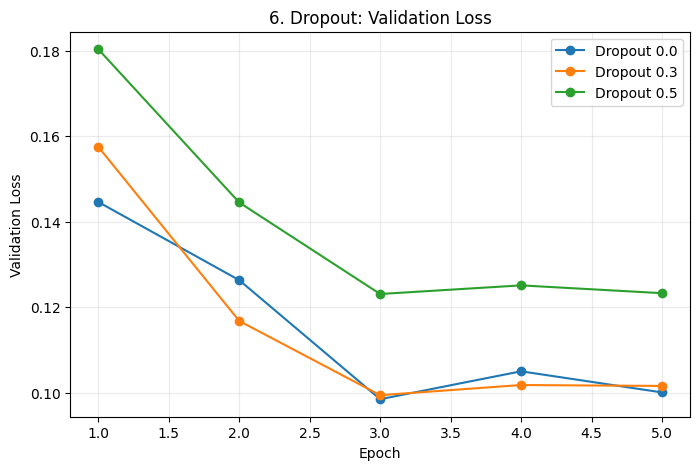

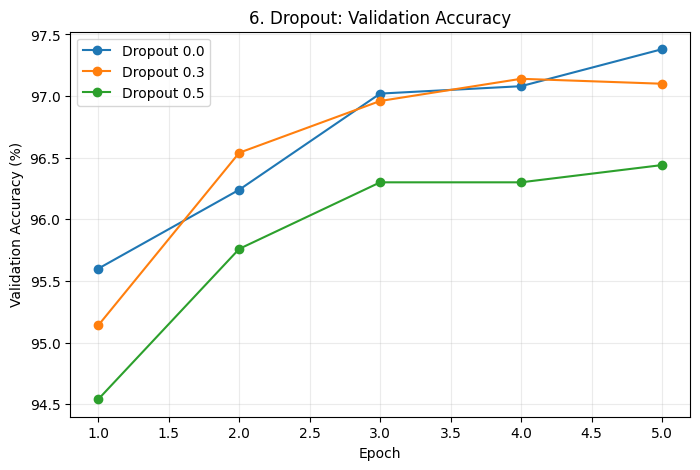

,Configuration,Final Train Loss,Final Train Accuracy,Final Val Loss,Final Val Accuracy,Test Loss,Test Accuracy,Train Time (s)
0,Dropout 0.0,0.0450,98.52,0.1000,97.38,0.0793,97.68,72.7
1,Dropout 0.3,0.1044,96.71,0.1016,97.10,0.0816,97.57,72.9
2,Dropout 0.5,0.1750,94.64,0.1233,96.44,0.1047,96.80,73.5


In [ ]:
for p in [0.0, 0.3, 0.5]:
    run_experiment(
        "6. Dropout",
        f"Dropout {p}",
        dropout=p
    )

plot_experiment("6. Dropout")

### Student task 6

1. Which model obtains the highest **training accuracy**?
2. Which obtains the highest **validation/test accuracy**?
3. What happens to the gap between training and validation accuracy?
4. Why can dropout lower training accuracy but still improve generalization?
5. What happens if dropout is too strong?

# Mini Challenge — Student Experiment

Choose **one new configuration** that was not tested above.

Examples:

- batch size = 64
- 256 hidden neurons
- 4 hidden layers
- dropout = 0.2
- learning rate = 0.005
- SGD with learning rate = 0.05

Before training, write a hypothesis:

> "I think __________ will happen because __________."

Then run the model, add the result to the comparison table, and decide whether the evidence supports your hypothesis.

In [ ]:
# TODO: Student challenge
#
# Example:
run_experiment(
    "7. Student Challenge",
    "My configuration",
    hidden_sizes=(256, 128),
    activation="relu",
    batch_size=64,
    lr=0.001,
    optimizer_name="adam",
    dropout=0.2
)
#
# plot_experiment("7. Student Challenge")

# Take-away

A neural network is not defined only by its layers.

Its learning behavior also depends on:

- **batch size** — how many samples estimate each update
- **depth** — model capacity and optimization difficulty
- **activation** — the nonlinear transformation and gradient behavior
- **learning rate** — update step size
- **optimizer** — the update rule
- **dropout** — regularization during training

The important skill is not memorizing one "best" setting.  
It is learning to **read loss/accuracy curves, design controlled experiments, and explain why training behavior changes**.